# Short DAPT ML

Baseline classification pipelines using cleaned feature matrix `../data/X_features.parquet` and target labels `../data/y_targets.parquet`. This notebook trains multi-output models and reports cross-validated and held-out test performance on the abbreviated DAPT subset.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

In [2]:
# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

Load the cleaned feature matrix `X` from `../data/X_features.parquet` and the 9 binary clinical outcome targets `y_df` from `../data/y_targets.parquet`, produced by the data cleaning pipeline.

In [3]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

target_features = y_df

In [4]:
X = X[X['regimen'] == 'abbreviated DAPT'].copy()

y_df = target_features.loc[X.index].copy()

## Explore Combined Target Groups

As a quick sanity check, group the 9 individual endpoints into two broad binary outcomes — *any bleeding event* (the 5 BARC-based bleeding targets) vs. *any ischemic event* (CV death, MI, stroke, revascularization) — and look at how often each combination occurs. This is purely exploratory and does not feed into the models below.

In [5]:
selected_target_cols = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]

y_df = y_df[selected_target_cols]

## Pipeline Evaluation Utilities

`evaluate_pipeline` reports cross-validated F1 score statistics (at the default 0.5 threshold) for each target of a single- or multi-output classification pipeline. `predict_with_threshold` generates predictions from a custom per-target probability threshold instead of 0.5, which matters for classifiers like RandomForest whose averaged probabilities rarely exceed 0.5 for rare events.

In [6]:
from thesis_utils import (
    evaluate_pipeline, predict_with_threshold, save_pipeline, plot_confusion_matrices,
    event_rate_thresholds, cv_roc_pr_curves,
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_df, test_size=0.2, random_state=42
)

## Multi-output Logistic Regression Pipeline

Split the data, build a scaling + logistic regression pipeline wrapped for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set.

Cross-validation on the training set



--- cec_barc235_335d ---
average_precision scores: [0.11011862 0.21649593 0.15453526 0.10070498 0.12185077]
Mean average_precision:   0.1407 ± 0.0420   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.03136969 0.07120834 0.0276001  0.04787483 0.03884637]
Mean average_precision:   0.0434 ± 0.0155   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.06702118 0.07108285 0.07931436 0.09192156 0.06722292]
Mean average_precision:   0.0753 ± 0.0094   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.07621326 0.00374532 0.007156   0.01321183 0.25515464]
Mean average_precision:   0.0711 ± 0.0958   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.20718052 0.17494118 0.28872632 0.15078651 0.16001989]
Mean average_precision:   0.1963 ± 0.0500   (positive rate / random AP = 0.0888)
Test set performance per target


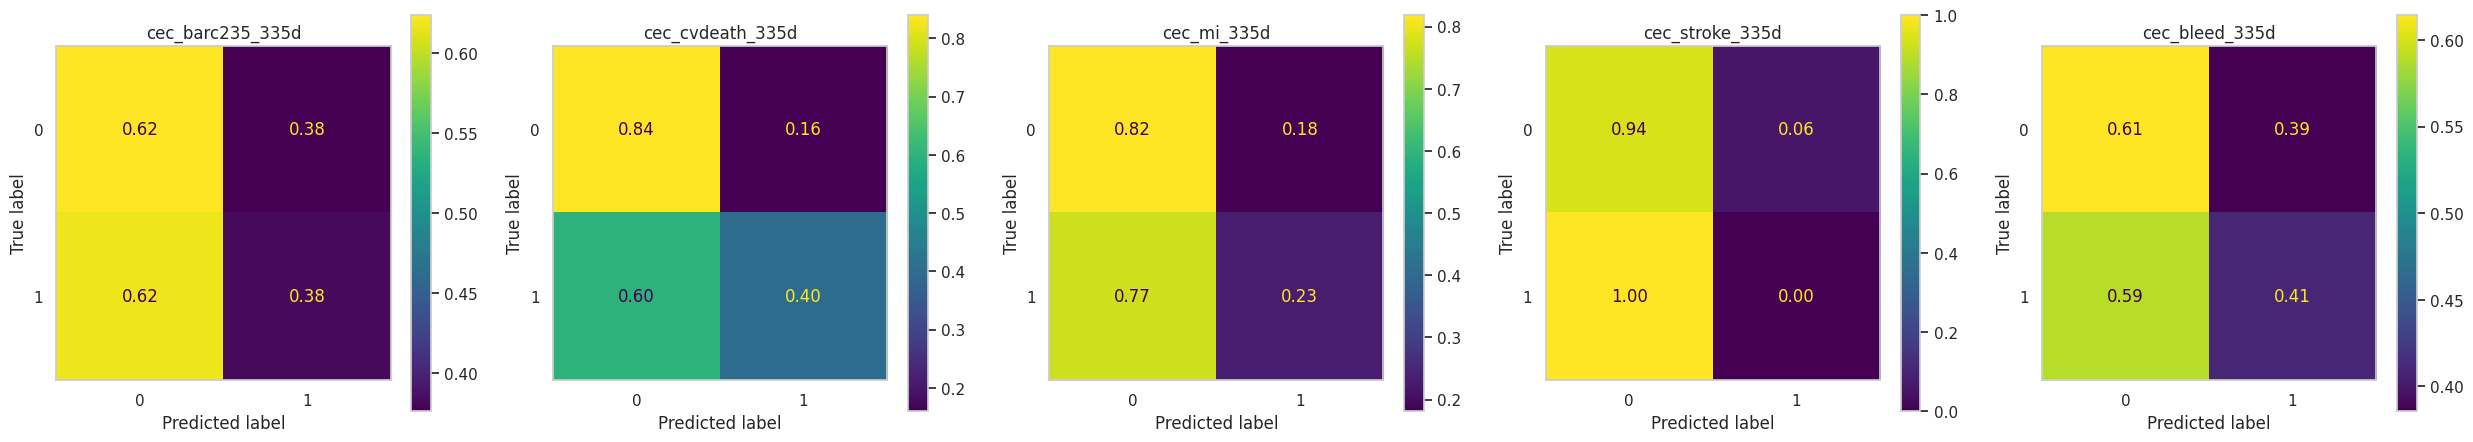

In [8]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# Each of the 9 endpoints is treated as an independent binary target, so the
# classifier is wrapped in MultiOutputClassifier (one LogisticRegression per
# target). class_weight='balanced' compensates for the severe class
# imbalance of these endpoints (1-11% positive rate, see 01_target_exploration).
pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
y_pred = pipe.predict(X_test)

plot_confusion_matrices(y_test, y_pred)

# Keep a handle to this fitted pipeline; only the single best model
# (highest mean PR-AUC across targets) is saved at the end of this section.
lr_pipe = pipe

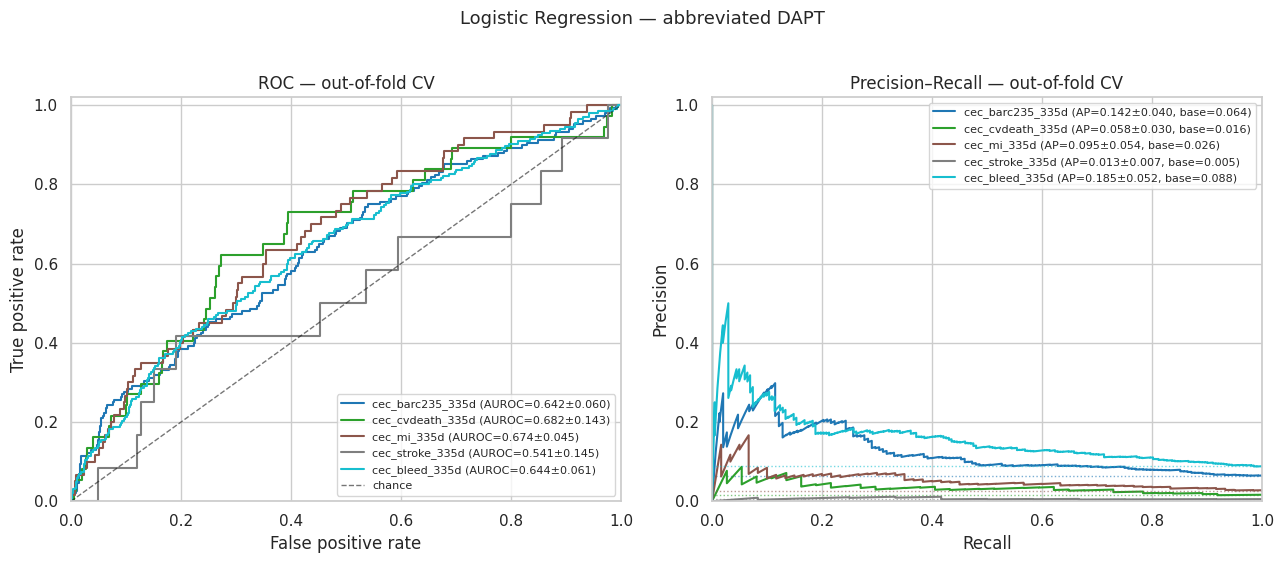

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.64,0.06,0.14,0.04,2.20
cec_cvdeath_335d,0.02,0.68,0.14,0.06,0.03,3.59
cec_mi_335d,0.03,0.67,0.05,0.10,0.05,3.65
cec_stroke_335d,0.01,0.54,0.14,0.01,0.01,2.42
cec_bleed_335d,0.09,0.64,0.06,0.19,0.05,2.10


In [9]:
# Threshold-free CV over the abbreviated-DAPT cohort: out-of-fold ROC / PR curves
# judge this model's discrimination without fixing a decision threshold (every
# row scored once while held out, preprocessing refit per fold -> no leakage).
# The leaky follow-up (fup_*) features are dropped here, as in bi-class/01; the
# baseline cell above still includes them (pending the same fix).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
lr_cv_summary = cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                                 model_name='Logistic Regression — abbreviated DAPT')
display(lr_cv_summary)

## Multi-output RandomForest Classification Pipeline

Split the data, build a scaling + random forest for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set. Predictions use a per-target probability threshold tuned to the training-set event rate instead of the default 0.5, since RandomForest's averaged probabilities rarely exceed 0.5 for these rare-event targets (the CV F1 scores above are still computed at the default threshold, so they remain low for the same reason).

Cross-validation on the training set



--- cec_barc235_335d ---
average_precision scores: [0.08107426 0.15090911 0.09451211 0.08816394 0.10363244]
Mean average_precision:   0.1037 ± 0.0248   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.03170336 0.04595082 0.01407563 0.01487368 0.03976983]
Mean average_precision:   0.0293 ± 0.0129   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.03625999 0.05725295 0.04799845 0.05811597 0.06505286]
Mean average_precision:   0.0529 ± 0.0099   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.07414596 0.0027248  0.0074867  0.03288153 0.03972104]
Mean average_precision:   0.0314 ± 0.0257   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.11131427 0.13755863 0.12502172 0.10682495 0.10953646]
Mean average_precision:   0.1181 ± 0.0116   (positive rate / random AP = 0.0888)
Test set performance per target


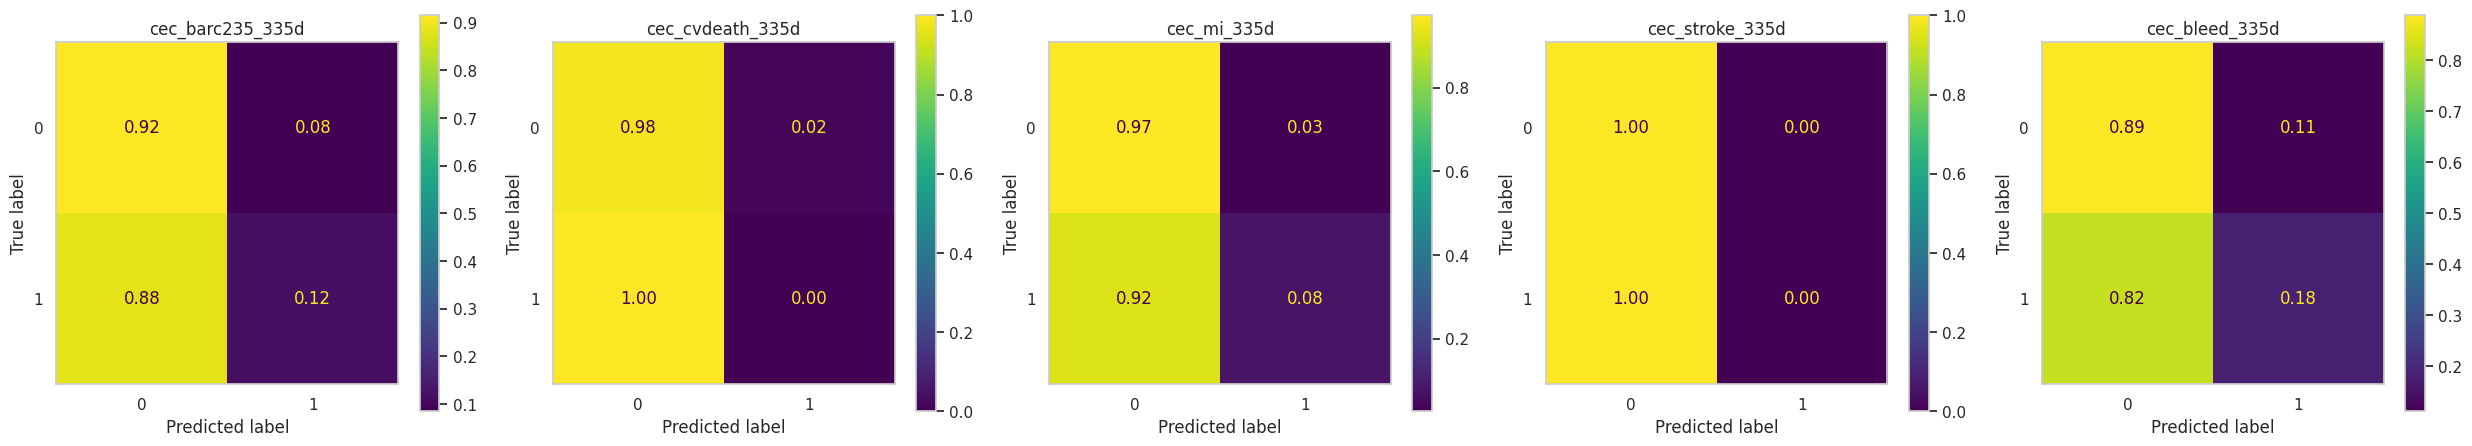

In [10]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One random forest per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(pipe, X_train, y_train)
y_pred = predict_with_threshold(pipe, X_test, thresholds)

plot_confusion_matrices(y_test, y_pred)

rf_pipe = pipe  # handle for the best-model selection below

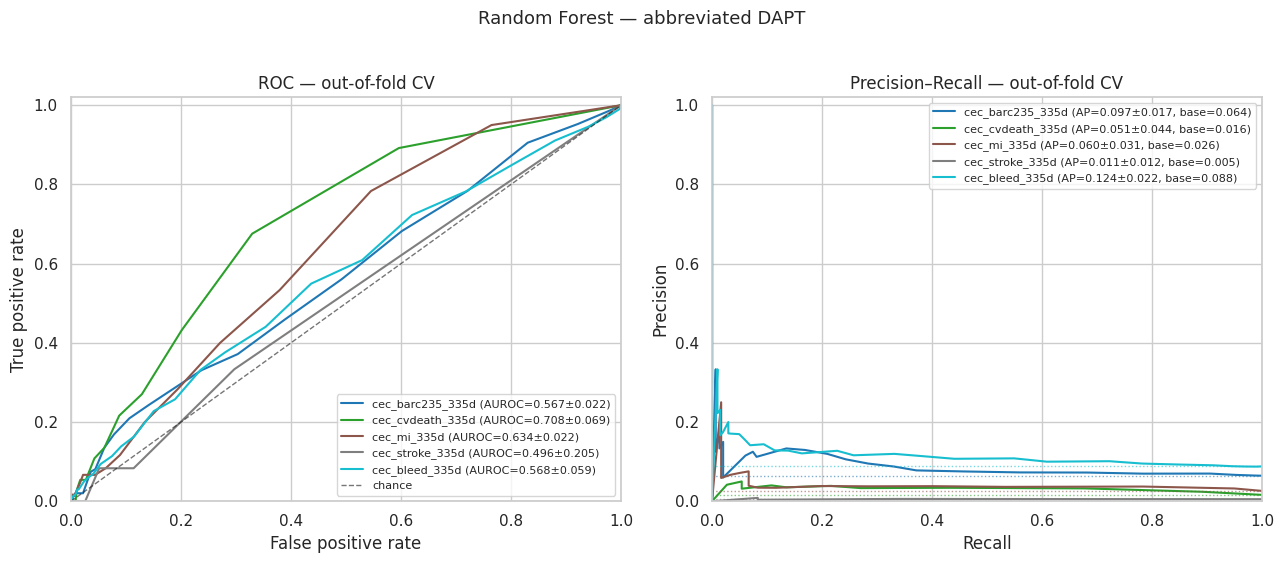

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.57,0.02,0.10,0.02,1.50
cec_cvdeath_335d,0.02,0.71,0.07,0.05,0.04,3.14
cec_mi_335d,0.03,0.63,0.02,0.06,0.03,2.29
cec_stroke_335d,0.01,0.50,0.21,0.01,0.01,2.12
cec_bleed_335d,0.09,0.57,0.06,0.12,0.02,1.41


In [11]:
# Out-of-fold ROC / PR curves for the Random Forest (see the LR cell above for
# the rationale: full-cohort CV, no threshold, fup_* leakage dropped).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
rf_cv_summary = cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                                 model_name='Random Forest — abbreviated DAPT')
display(rf_cv_summary)

Cross-validation on the training set



--- cec_barc235_335d ---
average_precision scores: [0.08843028 0.2412105  0.16661403 0.09893845 0.14705954]
Mean average_precision:   0.1485 ± 0.0548   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.02519006 0.22707027 0.02046834 0.0131556  0.05016895]
Mean average_precision:   0.0672 ± 0.0809   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.02568954 0.14893447 0.04069127 0.21262653 0.03821633]
Mean average_precision:   0.0932 ± 0.0744   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.00959657 0.0027248  0.00700699 0.00783784 0.52173913]
Mean average_precision:   0.1098 ± 0.2060   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.13390128 0.18232494 0.28928096 0.15904339 0.19749451]
Mean average_precision:   0.1924 ± 0.0530   (positive rate / random AP = 0.0888)
Test set performance per target


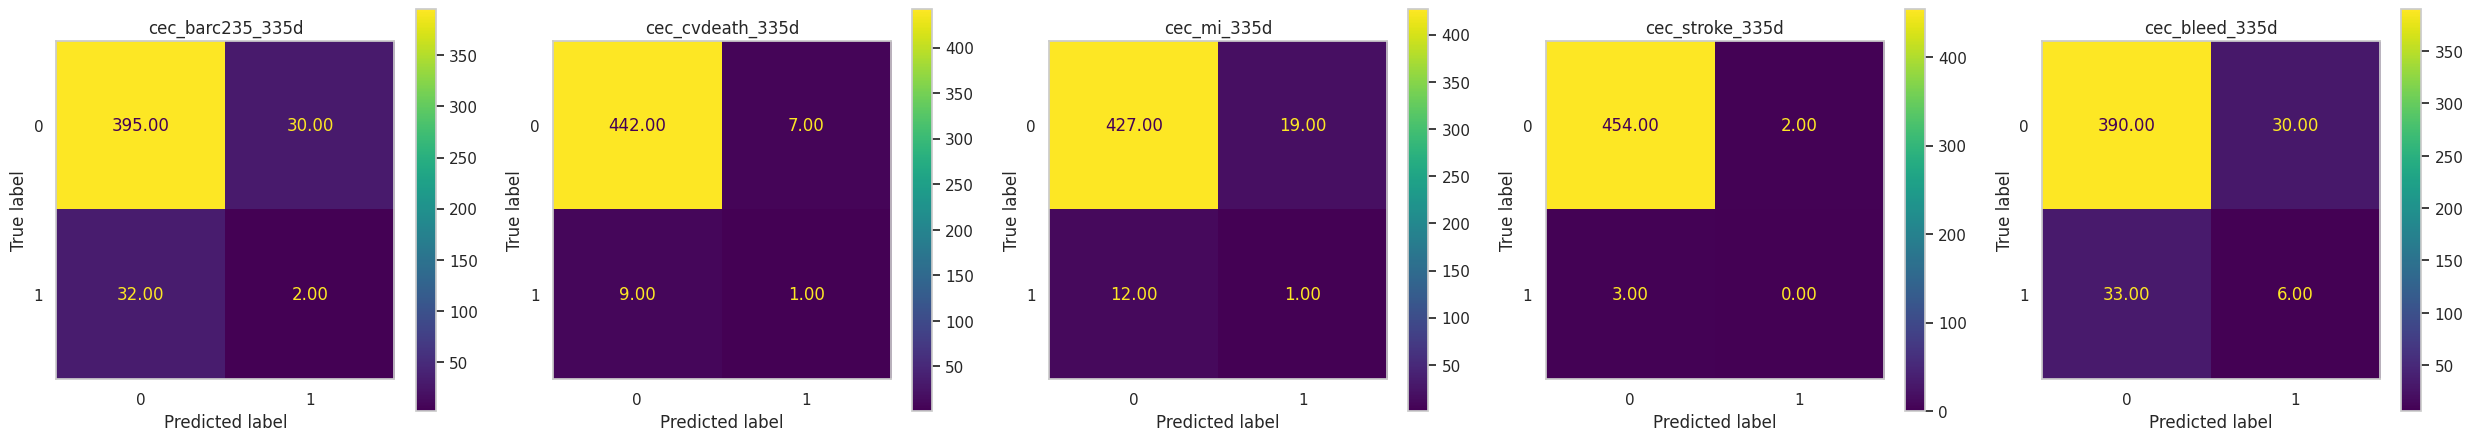

In [12]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One gradient boosting tree per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(pipe, X_train, y_train)
y_pred = predict_with_threshold(pipe, X_test, thresholds)

plot_confusion_matrices(y_test, y_pred, normalize=False)

gb_pipe = pipe  # handle for the best-model selection below

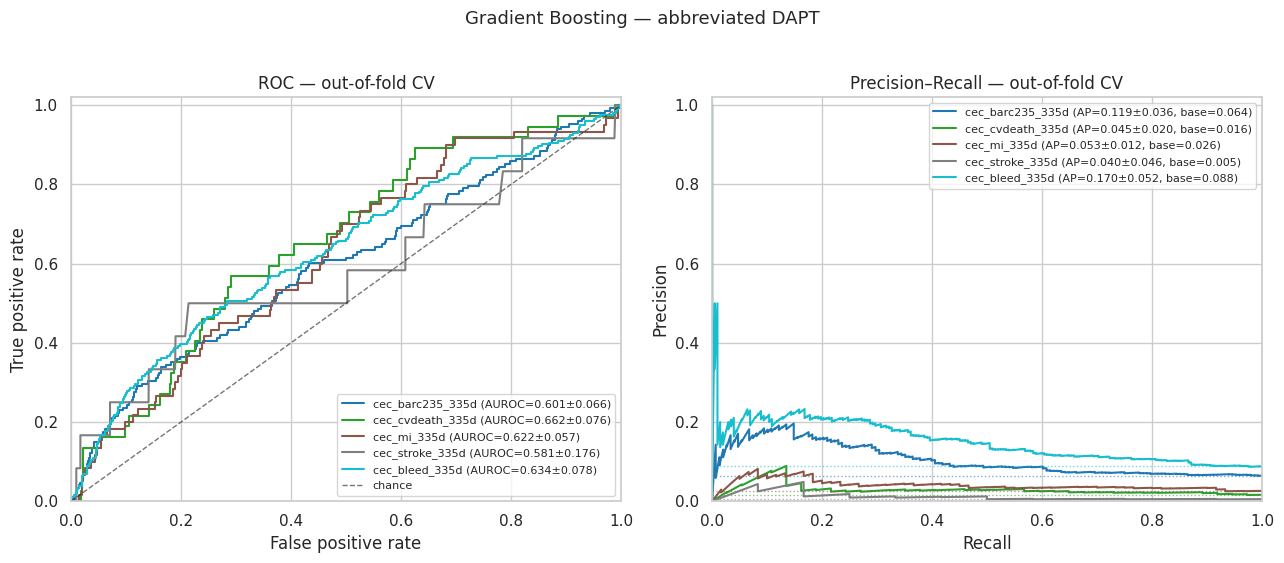

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.60,0.07,0.12,0.04,1.84
cec_cvdeath_335d,0.02,0.66,0.08,0.04,0.02,2.79
cec_mi_335d,0.03,0.62,0.06,0.05,0.01,2.01
cec_stroke_335d,0.01,0.58,0.18,0.04,0.05,7.70
cec_bleed_335d,0.09,0.63,0.08,0.17,0.05,1.93


In [13]:
# Out-of-fold ROC / PR curves for the Gradient Boosting model (see the LR cell
# above for the rationale: full-cohort CV, no threshold, fup_* leakage dropped).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
gb_cv_summary = cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                                 model_name='Gradient Boosting — abbreviated DAPT')
display(gb_cv_summary)

## Bayesian Hyperparameter Tuning

Random and grid search waste budget exploring the whole parameter space uniformly. Optuna's Tree-structured Parzen Estimator (TPE) builds a probabilistic model of the objective surface after each trial and concentrates subsequent trials where the objective is likely to be high.

**Objective**: mean macro precision across all targets on the training set (3-fold CV).
**Trials**: 50 / 30 / 20 for Logistic Regression / Random Forest / Gradient Boosting.
After the search, the best hyperparameters are used to fit the final model and evaluate it on the held-out test set — using the same evaluation protocol as the baseline models above (standard `.predict()` for LR, threshold-tuned probabilities for RF and GB).

In [14]:
import optuna
from sklearn.metrics import make_scorer, precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _multioutput_macro_precision(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return float(np.mean([
        precision_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
        for i in range(y_true.shape[1])
    ]))

_mo_scorer = make_scorer(_multioutput_macro_precision)


def mean_cv_precision(pipeline, X, y, cv=3):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=_mo_scorer, error_score=np.nan)
    return float(np.nanmean(scores))

### Logistic Regression

Search space: regularisation strength `C` (log-uniform in [0.001, 100]) and `solver` (lbfgs / liblinear / saga, all with L2 penalty).

In [15]:
def _lr_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    pipe = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            LogisticRegression(C=C, solver=solver, max_iter=2000,
                               random_state=42, class_weight='balanced'),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(_lr_objective, n_trials=50, show_progress_bar=True)

# Baseline (default C=1, lbfgs) for delta comparison
_baseline_lr_precision = mean_cv_precision(Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_lr.best_params)
print(f'Tuned  CV macro-precision: {study_lr.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_lr_precision:.4f}  '
      f'(Δ = {study_lr.best_value - _baseline_lr_precision:+.4f})')

Best trial: 0. Best value: 0.51969:   4%|▍         | 2/50 [00:10<04:09,  5.21s/it]/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The 

Best params: {'C': 2.0081700805573846, 'solver': 'saga'}
Tuned  CV macro-precision: 0.5229
Base   CV macro-precision: 0.5207  (Δ = +0.0023)


/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Test set performance — Tuned Logistic Regression

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.92      0.63      0.75       425
         1.0       0.07      0.32      0.11        34

    accuracy                           0.61       459
   macro avg       0.49      0.48      0.43       459
weighted avg       0.86      0.61      0.70       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.99      0.83      0.90       449
         1.0       0.06      0.50      0.11        10

    accuracy                           0.82       459
   macro avg       0.52      0.66      0.50       459
weighted avg       0.97      0.82      0.88       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89       446
         1.0       0.06      0.38      0.10        13

    accuracy                           0.80       459
   mac

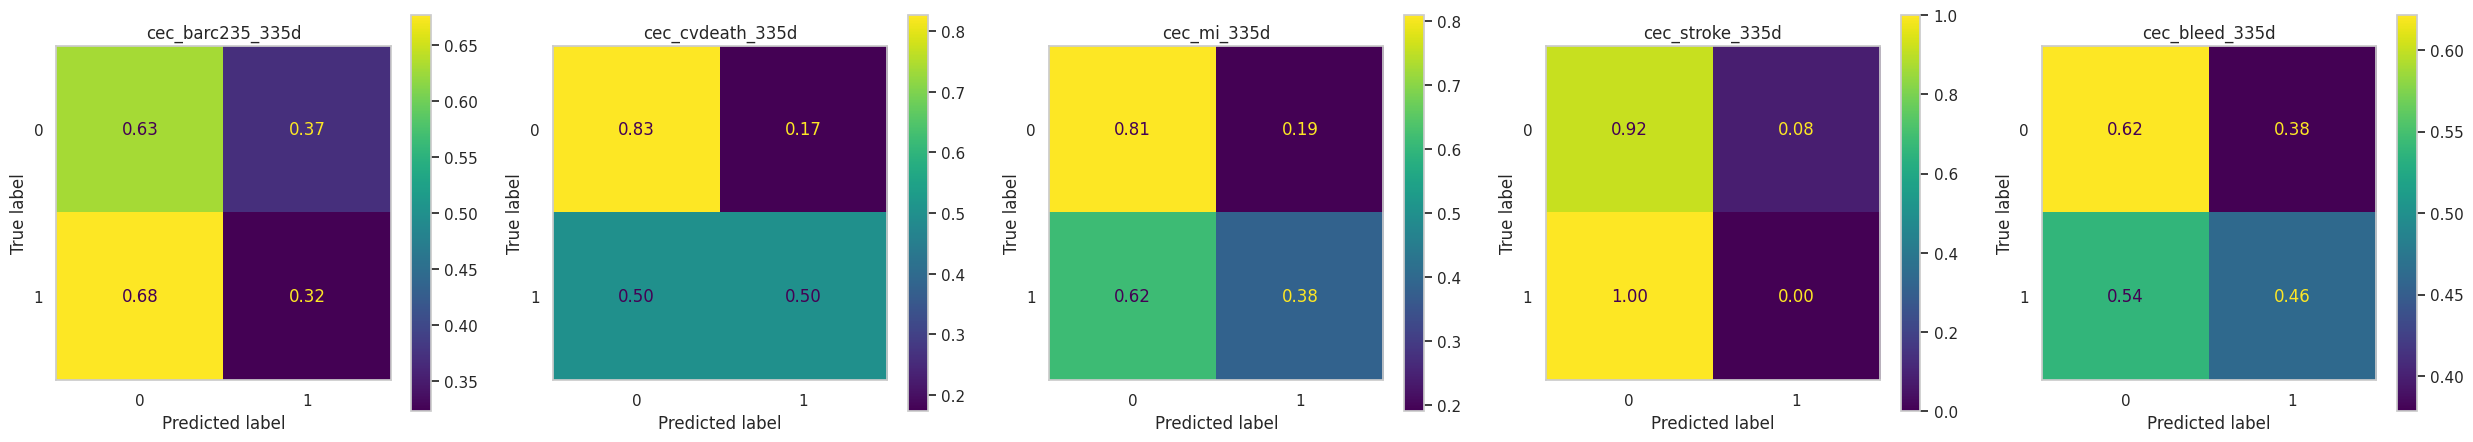

In [16]:
_p = study_lr.best_params
best_lr_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(C=_p['C'], solver=_p['solver'],
                           max_iter=2000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
])
best_lr_pipe.fit(X_train, y_train)

print('Test set performance — Tuned Logistic Regression')
_y_pred = best_lr_pipe.predict(X_test)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred)

### Random Forest

Search space: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`. For the test evaluation the per-target decision threshold is derived from the (1 − event_rate) quantile of the model's predicted training-set probabilities, making it adaptive to the actual probability range produced by the tuned hyperparameters.

In [17]:
def _rf_objective(trial):
    pipe = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                class_weight='balanced', random_state=42, n_jobs=2,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(_rf_objective, n_trials=50, show_progress_bar=True)

_baseline_rf_precision = mean_cv_precision(Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=2),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_rf.best_params)
print(f'Tuned  CV macro-precision: {study_rf.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_rf_precision:.4f}  '
      f'(Δ = {study_rf.best_value - _baseline_rf_precision:+.4f})')

Best trial: 39. Best value: 0.551321: 100%|██████████| 50/50 [02:30<00:00,  3.01s/it]


Best params: {'n_estimators': 400, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
Tuned  CV macro-precision: 0.5513
Base   CV macro-precision: 0.4804  (Δ = +0.0709)


Test set performance — Tuned Random Forest

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94       425
         1.0       0.12      0.09      0.10        34

    accuracy                           0.88       459
   macro avg       0.52      0.52      0.52       459
weighted avg       0.87      0.88      0.88       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       449
         1.0       0.00      0.00      0.00        10

    accuracy                           0.97       459
   macro avg       0.49      0.49      0.49       459
weighted avg       0.96      0.97      0.96       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       446
         1.0       0.05      0.08      0.06        13

    accuracy                           0.93       459
   macro avg

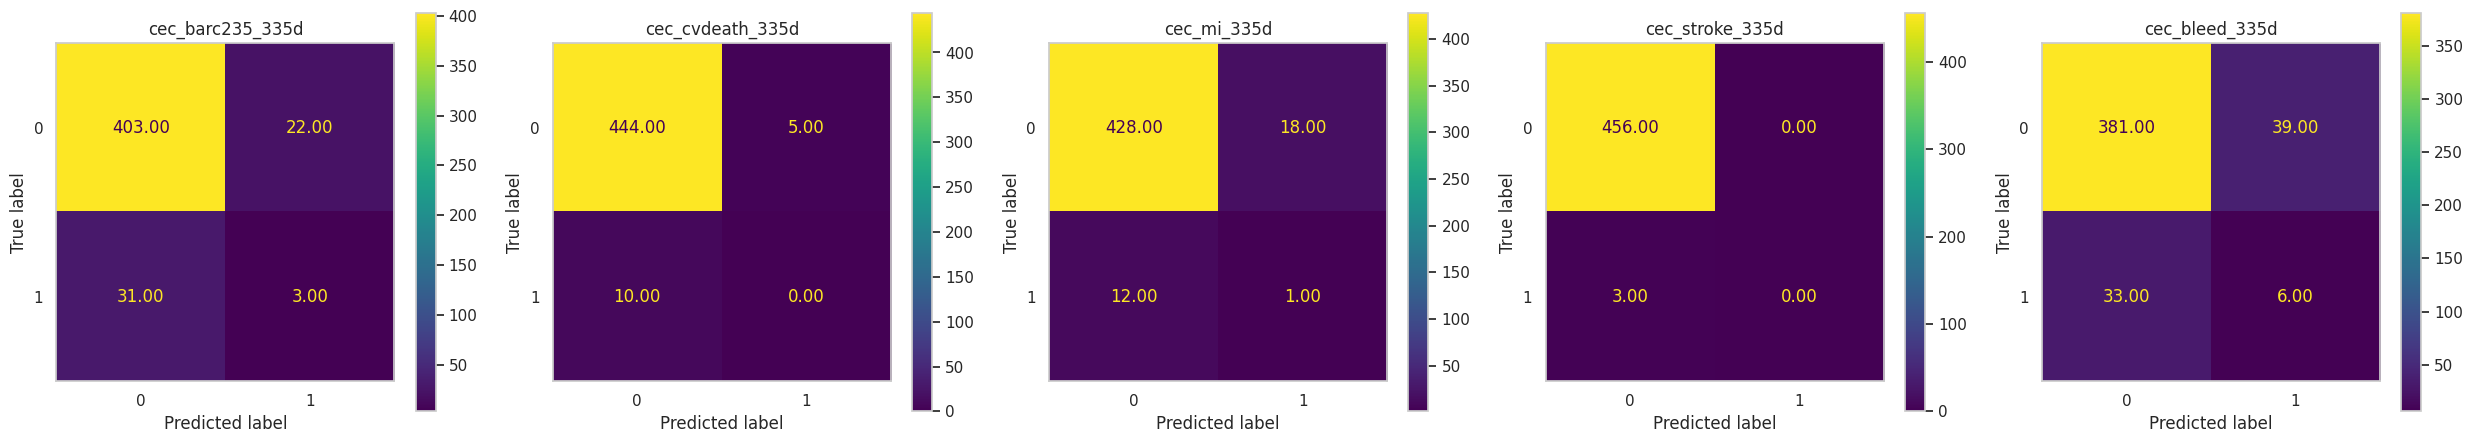

In [18]:
_p = study_rf.best_params
best_rf_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            min_samples_split=_p['min_samples_split'],
            min_samples_leaf=_p['min_samples_leaf'],
            max_features=_p['max_features'],
            class_weight='balanced', random_state=42, n_jobs=-1,
        ),
        n_jobs=-1,
    )),
])
best_rf_pipe.fit(X_train, y_train)

# Per-target thresholds from the (1 - event_rate) quantile of out-of-fold
# probabilities.  Using out-of-fold rather than in-sample probabilities is
# essential here: the tuned trees overfit the training set, so an in-sample
# quantile threshold lands far above the test probabilities and predicts the
# negative class for every row.
_thresholds = event_rate_thresholds(best_rf_pipe, X_train, y_train)

print('Test set performance — Tuned Random Forest')
_y_pred = predict_with_threshold(best_rf_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred, normalize=False)

### Gradient Boosting

Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_split`, `max_features`. Same quantile-based evaluation as RF.

In [19]:
def _gb_objective(trial):
    pipe = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 2, 6),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_gb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(_gb_objective, n_trials=50, show_progress_bar=True)

_baseline_gb_precision = mean_cv_precision(Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_gb.best_params)
print(f'Tuned  CV macro-precision: {study_gb.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_gb_precision:.4f}  '
      f'(Δ = {study_gb.best_value - _baseline_gb_precision:+.4f})')

Best trial: 41. Best value: 0.555035: 100%|██████████| 50/50 [01:35<00:00,  1.92s/it]


Best params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.29152983248737036, 'subsample': 0.6397206553506973, 'min_samples_split': 7, 'max_features': 'sqrt'}
Tuned  CV macro-precision: 0.5550
Base   CV macro-precision: 0.5688  (Δ = -0.0137)


Test set performance — Tuned Gradient Boosting

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92       425
         1.0       0.11      0.15      0.13        34

    accuracy                           0.85       459
   macro avg       0.52      0.53      0.52       459
weighted avg       0.87      0.85      0.86       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       449
         1.0       0.00      0.00      0.00        10

    accuracy                           0.98       459
   macro avg       0.49      0.50      0.49       459
weighted avg       0.96      0.98      0.97       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.96      0.39      0.56       446
         1.0       0.02      0.46      0.04        13

    accuracy                           0.39       459
   macro

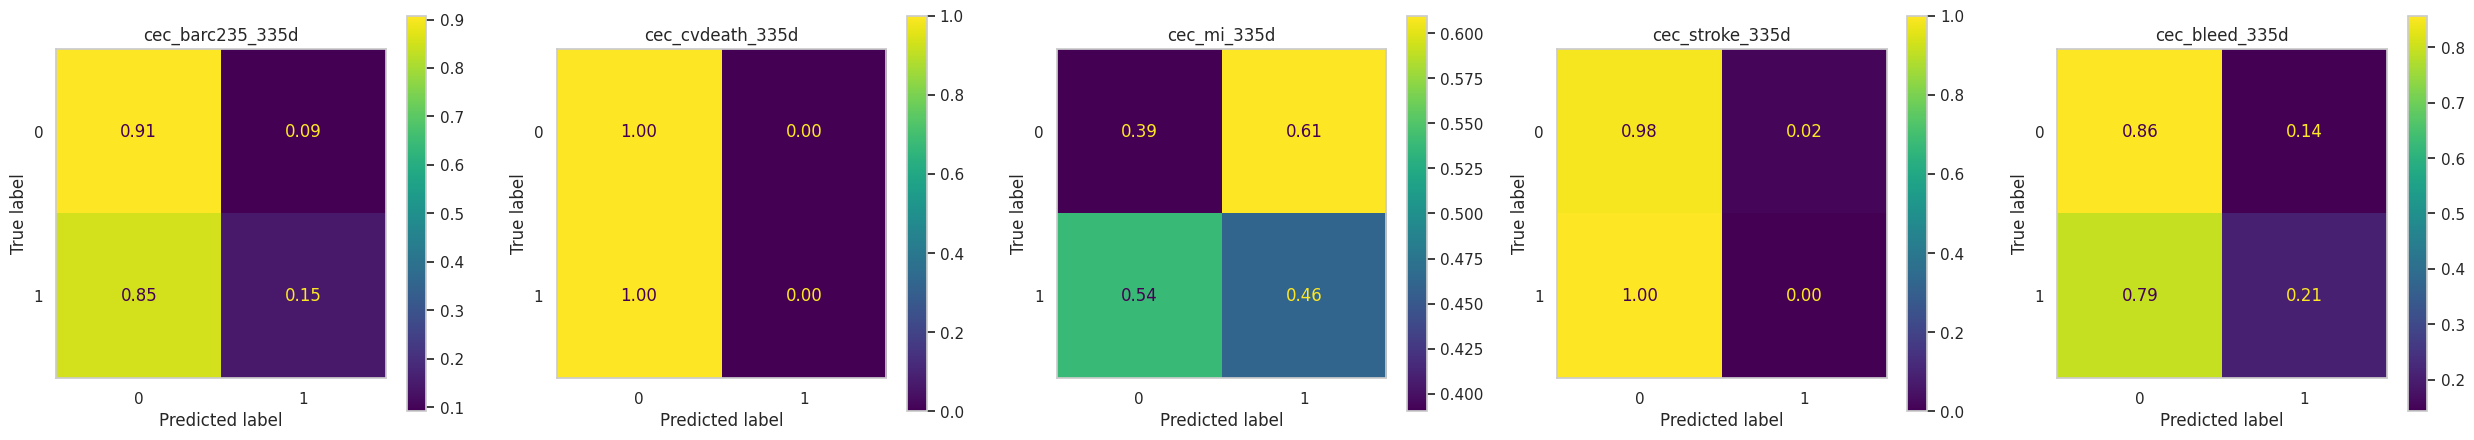

In [20]:
_p = study_gb.best_params
best_gb_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            learning_rate=_p['learning_rate'], subsample=_p['subsample'],
            min_samples_split=_p['min_samples_split'], max_features=_p['max_features'],
            random_state=42,
        ),
        n_jobs=-1,
    )),
])
best_gb_pipe.fit(X_train, y_train)

# Same out-of-fold quantile thresholds as for the tuned RF above, for consistency.
_thresholds = event_rate_thresholds(best_gb_pipe, X_train, y_train)

print('Test set performance — Tuned Gradient Boosting')
_y_pred = predict_with_threshold(best_gb_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred)

### Summary

Comparison of cross-validated mean macro precision (3-fold, training set) before and after Bayesian tuning, and the convergence of the best-so-far objective across trials.

              Model  Baseline CV Precision  Tuned CV Precision  Δ Precision
Logistic Regression                   0.52                0.52         0.00
      Random Forest                   0.48                0.55         0.07
  Gradient Boosting                   0.57                0.56        -0.01


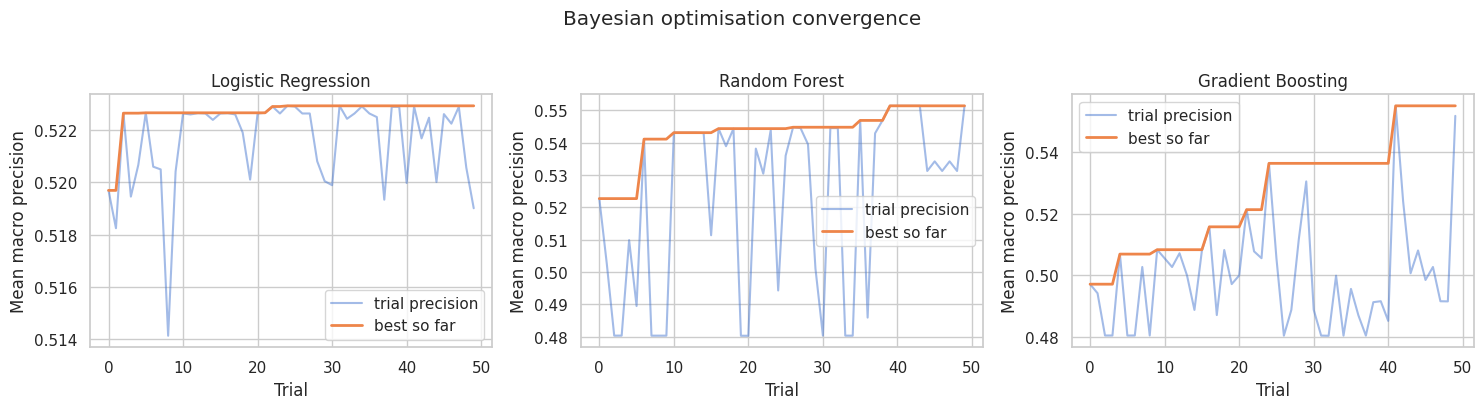

In [21]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline CV Precision': [_baseline_lr_precision, _baseline_rf_precision, _baseline_gb_precision],
    'Tuned CV Precision':    [study_lr.best_value, study_rf.best_value, study_gb.best_value],
})
comparison['Δ Precision'] = comparison['Tuned CV Precision'] - comparison['Baseline CV Precision']
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, study) in zip(
    axes,
    [('Logistic Regression', study_lr),
     ('Random Forest',       study_rf),
     ('Gradient Boosting',   study_gb)],
):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.5, label='trial precision')
    ax.plot(best_so_far, linewidth=2, label='best so far')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Mean macro precision')
    ax.legend()
plt.suptitle('Bayesian optimisation convergence', y=1.02)
plt.tight_layout()
plt.show()

## Save the Best Model

Now that the tuned pipelines exist, every candidate — the three baseline pipelines **and** their Bayesian-tuned counterparts — is re-scored with the same threshold-free, out-of-fold cross-validation used for the baselines above, and only the single best one (highest **mean PR-AUC across the targets**) is persisted into `Meta-learning/models/`. The tuned models are re-scored on PR-AUC because the Optuna search optimised a different CV objective, so a tuned model is not guaranteed to beat its baseline here. Any model previously saved for this DAPT variant is removed first, so `models/` always holds exactly one pipeline per variant — the convention the downstream CATE notebook relies on when it loads them.

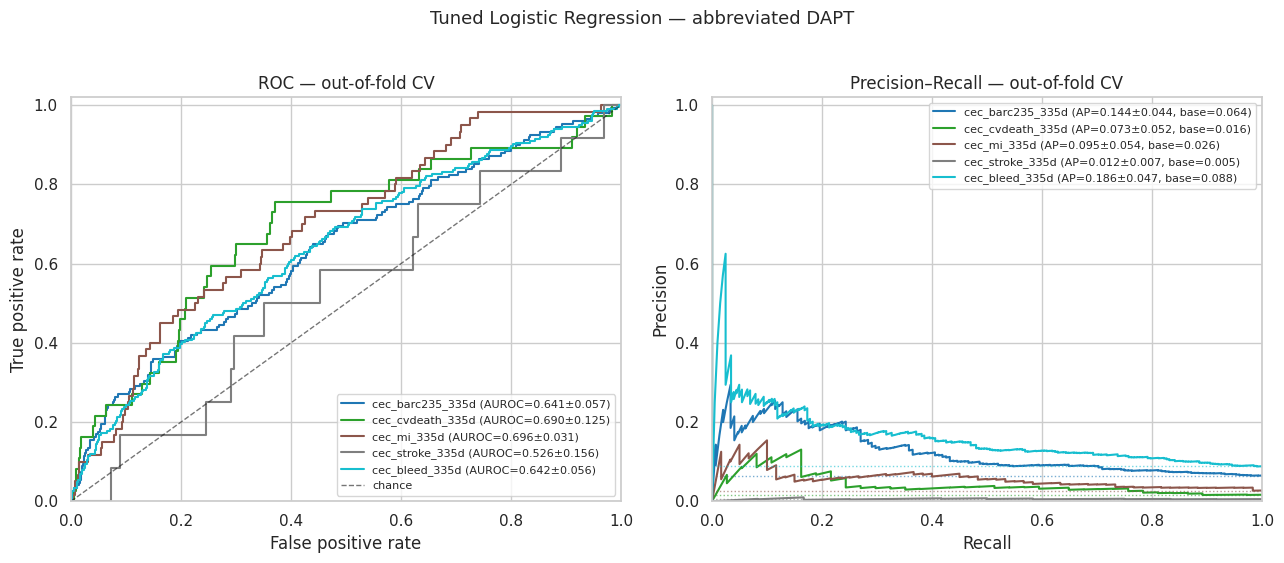

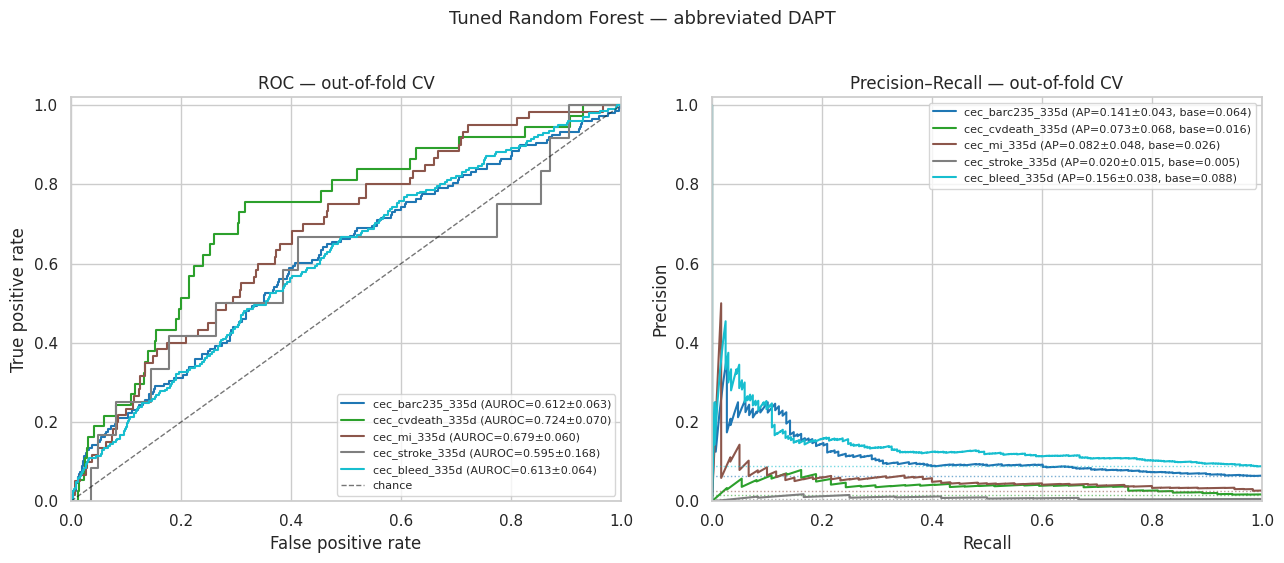

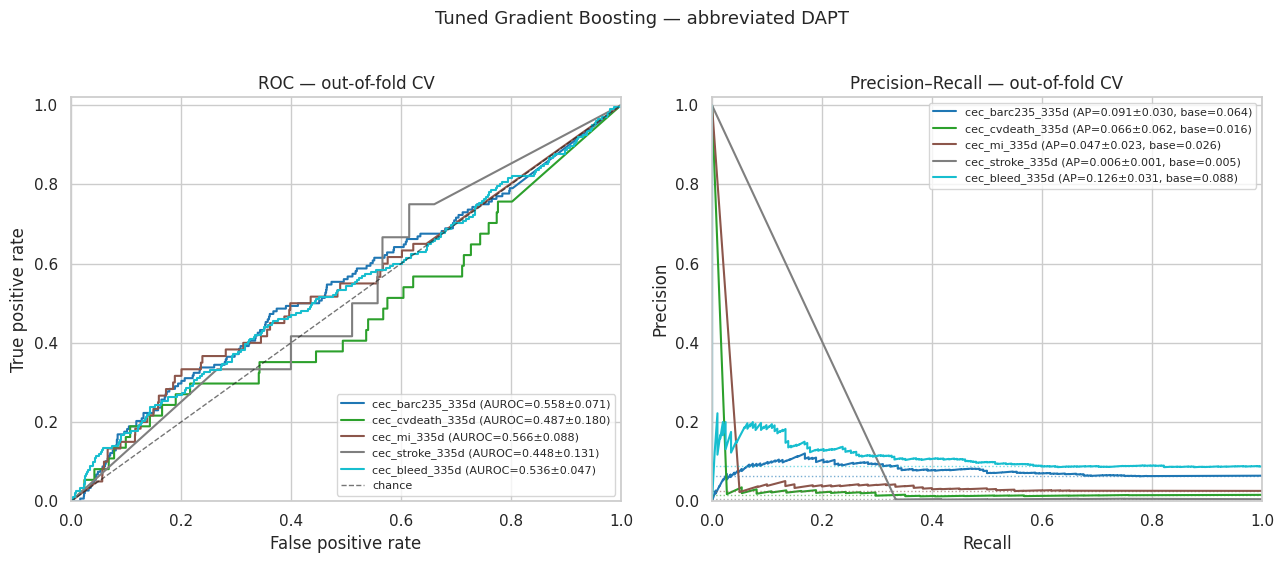

Mean out-of-fold performance across targets (baseline + tuned):
                            mean_AUROC  mean_AUPRC  mean_AUPRC_lift
LogisticRegression (tuned)        0.64        0.10             2.95
LogisticRegression                0.64        0.10             2.79
RandomForest (tuned)              0.64        0.09             3.10
GradientBoosting                  0.62        0.09             3.25
RandomForest                      0.59        0.07             2.09
GradientBoosting (tuned)          0.52        0.07             1.98

Best model by mean AUPRC: LogisticRegression (tuned) (mean_AUPRC=0.1020)
Saved best model -> /home/tpioda/Bachelor-Thesis/Meta-learning/models/base_models/LR_gf_multioutput_sDAPT.joblib


In [22]:
# ---- Select and persist only the best model (baseline + tuned) -----------
# Rank EVERY candidate -- the three baseline pipelines AND their Bayesian-
# tuned counterparts -- by out-of-fold, threshold-free PR-AUC averaged over
# the targets, and save ONLY the single overall winner. The tuned pipelines
# are re-scored with the same cv_roc_pr_curves protocol as the baselines so
# the comparison is apples-to-apples: the Optuna search optimised a different
# CV objective, so a tuned model is not guaranteed to win on mean PR-AUC.
import glob

RANK_METRIC = 'AUPRC'   # 'AUPRC' (PR-AUC) | 'AUROC' | 'AUPRC_lift'

# Same leakage-free, full-cohort matrix used for the baseline CV curves above.
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])

# Threshold-free out-of-fold summaries for the tuned pipelines (the baselines
# already have lr_cv_summary / rf_cv_summary / gb_cv_summary from above).
lr_tuned_cv_summary = cv_roc_pr_curves(best_lr_pipe, _X_cv, y_df, cv=5,
                                       model_name='Tuned Logistic Regression — abbreviated DAPT')
rf_tuned_cv_summary = cv_roc_pr_curves(best_rf_pipe, _X_cv, y_df, cv=5,
                                       model_name='Tuned Random Forest — abbreviated DAPT')
gb_tuned_cv_summary = cv_roc_pr_curves(best_gb_pipe, _X_cv, y_df, cv=5,
                                       model_name='Tuned Gradient Boosting — abbreviated DAPT')

# (pipeline, cv_summary, filename) per candidate. A baseline and its tuned
# variant share a filename: the saved name encodes the winning ALGORITHM and
# DAPT variant, which is all the downstream CATE notebook parses.
candidates = {
    'LogisticRegression':        (lr_pipe,      lr_cv_summary,       'LR_gf_multioutput_sDAPT'),
    'RandomForest':              (rf_pipe,      rf_cv_summary,       'RF_gf_multioutput_sDAPT'),
    'GradientBoosting':          (gb_pipe,      gb_cv_summary,       'GB_gf_multioutput_sDAPT'),
    'LogisticRegression (tuned)':(best_lr_pipe, lr_tuned_cv_summary, 'LR_gf_multioutput_sDAPT'),
    'RandomForest (tuned)':      (best_rf_pipe, rf_tuned_cv_summary, 'RF_gf_multioutput_sDAPT'),
    'GradientBoosting (tuned)':  (best_gb_pipe, gb_tuned_cv_summary, 'GB_gf_multioutput_sDAPT'),
}

leaderboard = pd.DataFrame({
    name: {
        'mean_AUROC':      summary['AUROC'].mean(),
        'mean_AUPRC':      summary['AUPRC'].mean(),
        'mean_AUPRC_lift': summary['AUPRC_lift'].mean(),
    }
    for name, (_, summary, _) in candidates.items()
}).T.sort_values(f'mean_{RANK_METRIC}', ascending=False)
print('Mean out-of-fold performance across targets (baseline + tuned):')
print(leaderboard.round(4).to_string())

best_name = leaderboard.index[0]
best_pipe, _, best_filename = candidates[best_name]
print(f"\nBest model by mean {RANK_METRIC}: {best_name} "
      f"(mean_{RANK_METRIC}={leaderboard.loc[best_name, f'mean_{RANK_METRIC}']:.4f})")

# Keep exactly one model per DAPT variant: drop any previously saved
# *_sDAPT.joblib (e.g. a different algorithm won on a past run) before saving,
# so the downstream CATE notebook never loads a stale duplicate.
_variant = best_filename.split('_')[-1]   # 'sDAPT'
for _stale in glob.glob(os.path.join(MODELS_DIR, 'base_models', f'*_{_variant}.joblib')):
    os.remove(_stale)

best_model_path = os.path.join(MODELS_DIR, 'base_models', best_filename + '.joblib')
save_pipeline(best_model_path, best_pipe)
print(f"Saved best model -> {best_model_path}")